# Scenario versions and difficulty levels

pystorms 2.0 adds two keywords to every scenario.

`version` selects the network. `"1"` is the original scenario as published;
`"2"` is a harder variant of the same network, available for alpha, theta,
gamma, delta and epsilon.

`level` decides how honest the instrumentation is. `"1"` is a perfect world.
`"2"` adds sensor noise, slow drift and calibration bias, and lets valves stick
for a while. `"3"` turns all of that up and adds sensors that drop out
entirely.

They are independent, so you can hold the network fixed and vary only the
measurement quality, which is usually what you want when testing whether a
controller is robust or merely tuned.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pystorms

print("pystorms", pystorms.__version__)

plt.rcParams.update({"font.size": 14})
plt.style.use("seaborn-v0_8-whitegrid")

pystorms 2.0.0


## One important detail

`level` has to be passed in two places: once when you build the scenario, which
draws the fault schedule, and again on every `state()` and `step()` call, which
applies it.

```python
env = pystorms.scenarios.theta(level="2")   # draws the faults
state = env.state(level="2")                # applies the noise
done = env.step(actions, level="2")         # applies the stuck valves
```

If they disagree you will either silently get clean readings or an
`AttributeError`. Keeping the level in a variable and passing that variable
everywhere is the way to stay out of trouble.

## Version 1 against version 2

Same controller, same scenario, different network.

In [2]:
def run(version="1", level="1", seed=None):
    """Run theta with both valves half open and return its performance."""
    if seed is not None:
        np.random.seed(seed)

    env = pystorms.scenarios.theta(version=version, level=level)
    n = len(env.env.config["action_space"])

    done = False
    while not done:
        env.state(level=level)
        done = env.step(np.ones(n) * 0.5, level=level)

    return env.performance()


for version in ["1", "2"]:
    print(f"theta version {version}: {run(version=version):.1f}")

theta version 1: 1626.2
theta version 2: 6913.3


Version 2 halves the objective's threshold, shrinks one of the basins and
ends the storm sooner, so the same fixed control does considerably worse. That
is the point: version 2 leaves less room for a mediocre controller to look
good.

## What the levels do to a measurement

Level 1 hands you the true depth. Levels 2 and 3 hand you something noisier and
biased, drifting further from the truth as the simulation runs.

In [3]:
traces = {}
for level in ["1", "2", "3"]:
    np.random.seed(0)
    env = pystorms.scenarios.theta(level=level)

    readings, steps, done = [], 0, False
    while not done:
        readings.append(env.state(level=level)[0])
        done = env.step(np.ones(2) * 0.5, level=level)
        steps += 1
    traces[level] = np.asarray(readings)

pd.DataFrame({f"level {k}": pd.Series(v).describe() for k, v in traces.items()}).round(3)

,level 1,level 2,level 3
count,12578.000,12578.000,12578.000
mean,0.037,0.037,0.058
std,0.052,0.058,0.156
min,0.000,-0.105,-0.589
25%,0.000,-0.005,-0.045
50%,0.001,0.020,0.057
75%,0.066,0.069,0.161
max,0.158,0.237,0.672


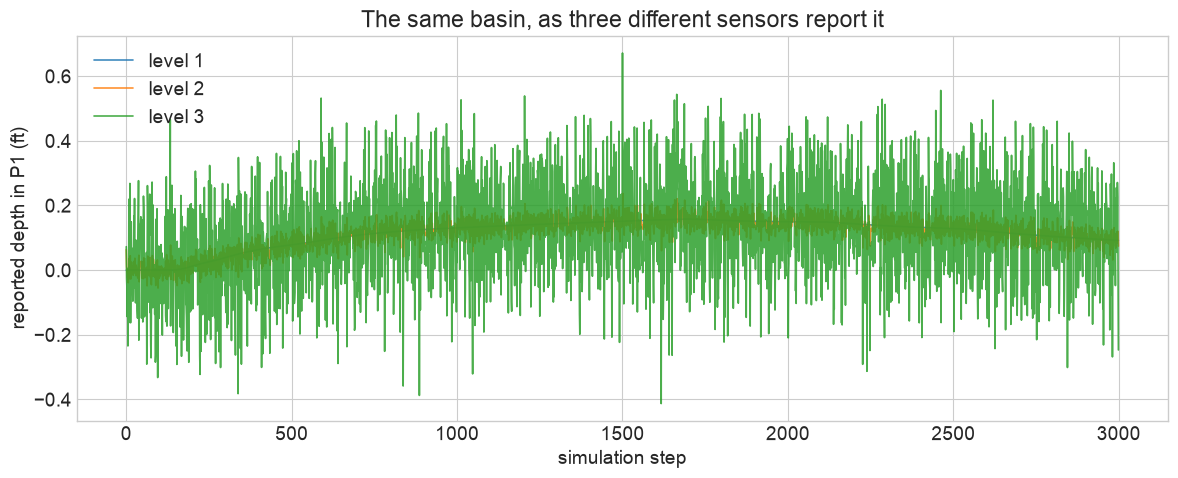

In [4]:
fig, ax = plt.subplots(figsize=(12, 5))
window = slice(0, 3000)
for level, style in zip(["1", "2", "3"], ["-", "-", "-"]):
    ax.plot(traces[level][window], style, linewidth=1.2, alpha=0.85,
            label=f"level {level}")
ax.set_xlabel("simulation step")
ax.set_ylabel("reported depth in P1 (ft)")
ax.set_title("The same basin, as three different sensors report it")
ax.legend()
plt.tight_layout()

The level 1 line is the ground truth. Level 2 wobbles around it. Level 3
is noticeably worse, and the flat stretches are the sensor dropping out
entirely, which the scenario reports as a depth of zero.

## Faults are random, so seed them

The drift rates, the bias and the stuck valve schedule are drawn when the
scenario is constructed, from numpy's global random state. Two runs of the same
scenario are therefore not the same experiment unless you seed first.

In [5]:
print("without seeding, three runs of the same scenario:")
for _ in range(3):
    print(f"  {run(level='2'):.1f}")

print("\nseeding first:")
for _ in range(3):
    print(f"  {run(level='2', seed=7):.1f}")

without seeding, three runs of the same scenario:


  1626.2
  1626.2


  1626.2

seeding first:


  1626.2


  1626.2


  1626.2


There is no `seed` argument on the scenarios themselves, so seeding
`numpy.random` before construction is currently the only way to make a level 2
or level 3 comparison repeatable. Do it once at the top of a benchmark script,
and record the seed alongside the numbers.

## Comparing controllers fairly across levels

The useful question is not how a controller scores at level 1 but how much of
that score survives when the instrumentation degrades. Averaging over several
seeds keeps a single lucky fault schedule from deciding the answer.

In [6]:
def equal_filling(depths, max_depth=2.0, tolerance=0.5):
    """Release from whichever basin is fuller relative to the average."""
    filling = depths / max_depth
    deviation = filling - filling.mean()
    return np.clip(0.5 + deviation / tolerance, 0.0, 1.0)


def evaluate(controller, level, seeds=(1, 2, 3)):
    scores = []
    for seed in seeds:
        np.random.seed(seed)
        env = pystorms.scenarios.theta(level=level)
        done = False
        while not done:
            state = env.state(level=level)
            done = env.step(controller(state), level=level)
        scores.append(env.performance())
    return np.mean(scores), np.std(scores)


rows = []
for level in ["1", "2", "3"]:
    mean_ef, std_ef = evaluate(equal_filling, level)
    mean_fixed, std_fixed = evaluate(lambda s: np.ones(2) * 0.5, level)
    rows.append({"level": level,
                 "equal filling": round(mean_ef, 1),
                 "equal filling sd": round(std_ef, 1),
                 "fixed 0.5": round(mean_fixed, 1),
                 "fixed 0.5 sd": round(std_fixed, 1)})

pd.DataFrame(rows).set_index("level")

,equal filling,equal filling sd,fixed 0.5,fixed 0.5 sd
level,,,,
1,1628.1,0.0,1626.2,0.0
2,1628.2,0.0,1626.2,0.0
3,1628.6,0.7,1626.2,0.0


## Exercises

1. Run the comparison above on `version="2"` as well, and check whether the
   ranking of the two controllers holds when both the network and the
   instrumentation get harder.
2. The equal filling controller reacts to whatever the sensor reports, dropouts
   included. Add a simple filter, for instance ignoring a reading that jumps
   implausibly far in one step, and measure how much of the level 3 penalty it
   recovers.
3. Widen the seed set from three to twenty. How many seeds do you need before
   the level 3 comparison stops changing its mind?